# Part 1 — Data collection and preprocessing**Course:** CS-GY 6923 · **Spec:** `optional-project-spring26.pdf` (Part 1, ~15%)This notebook implements **Part 1**: HuggingFace SVG corpora, cleaning/normalization,BPE tokenization, **98% / 1% / 1% train/val/test by file**, **≥100M training tokens**,and dataset statistics + rendered examples for the report.

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE = '/content/drive/MyDrive/svg_scaling_v2'
for d in [DRIVE, f'{DRIVE}/data', f'{DRIVE}/checkpoints',
          f'{DRIVE}/plots', f'{DRIVE}/samples', f'{DRIVE}/results']:
    os.makedirs(d, exist_ok=True)
print("drive mounted, dirs ready")

Mounted at /content/drive
drive mounted, dirs ready


In [2]:
!pip install -q datasets tokenizers lxml cairosvg Pillow tqdm numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 4.6 MB/s eta 0:00:00


In [3]:
import os, re, json, random, hashlib, warnings
from io import BytesIO

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from lxml import etree

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
print("imports done")

imports done


## 1.1 Download the datasetsUsing starvector datasets from HuggingFace. Primary: svg-icons-simple (~89K icons).Adding emoji, fonts, stack, svgen to reach 100M+ tokens.

In [4]:
from datasets import load_dataset

print("loading icons...")
icons = load_dataset("starvector/svg-icons-simple", split="train")
print(f"  {len(icons):,} icons")

print("loading emoji...")
emoji = load_dataset("starvector/svg-emoji-simple", split="train")
print(f"  {len(emoji):,} emoji")

print("loading fonts (subsampling)...")
fonts = load_dataset("starvector/svg-fonts-simple", split="train")
fonts = fonts.shuffle(seed=42).select(range(min(100000, len(fonts))))
print(f"  {len(fonts):,} fonts (subsampled)")

has_stack = True
try:
    print("loading stack (subsampling)...")
    stack = load_dataset("starvector/svg-stack-simple", split="train")
    stack = stack.shuffle(seed=42).select(range(min(120000, len(stack))))
    print(f"  {len(stack):,} stack")
except Exception as e:
    has_stack = False
    print(f"  stack unavailable: {e}")

has_svgen = True
try:
    print("loading svgen...")
    svgen = load_dataset("starvector/svgen-500k", split="train")
    svgen = svgen.shuffle(seed=42).select(range(min(150000, len(svgen))))
    print(f"  {len(svgen):,} svgen")
except Exception as e:
    has_svgen = False
    print(f"  svgen unavailable: {e}")

loading icons...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/137M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/4.59M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/11.1M [00:00<?, ?B/s]

...

data/val-00000-of-00001.parquet:   0%|          | 0.00/181M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1229633 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3235 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/61507 [00:00<?, ? examples/s]

  120,000 stack
loading svgen...
  svgen unavailable: Dataset 'starvector/svgen-500k' doesn't exist on the Hub or cannot be accessed.


## 1.2 Clean the SVGsStrip comments, normalize coordinates to 1 decimal place, validate XML.

In [5]:
def get_svg(ex):
    for col in ['svg', 'Svg', 'content', 'text', 'svg_code', 'SVG', 'image', 'output']:
        if col in ex and isinstance(ex[col], str) and len(ex[col]) > 10:
            return ex[col]
    for col in ex:
        val = ex[col]
        if isinstance(val, str) and '<svg' in val.lower():
            return val
    return None

def clean_svg(s):
    if not s or not isinstance(s, str):
        return None
    # strip comments, processing instructions, DOCTYPE
    s = re.sub(r'<!--.*?-->', '', s, flags=re.DOTALL)
    s = re.sub(r'<\?.*?\?>', '', s, flags=re.DOTALL)
    s = re.sub(r'<!DOCTYPE[^>]*>', '', s, flags=re.DOTALL)
    # collapse whitespace
    s = re.sub(r'\s+', ' ', s).strip()
    # round numbers to 1 decimal
    s = re.sub(r'(\d+\.\d{2,})', lambda m: f"{float(m.group()):.1f}", s)
    # validate XML
    try:
        root = etree.fromstring(s.encode('utf-8'))
        tag = root.tag.split('}')[-1] if '}' in root.tag else root.tag
        if tag != 'svg':
            return None
        return etree.tostring(root, encoding='unicode')
    except:
        return None

# process everything
all_svgs = []
datasets = [(icons, "icons"), (emoji, "emoji"), (fonts, "fonts")]
if has_stack:
    datasets.append((stack, "stack"))
if has_svgen:
    datasets.append((svgen, "svgen"))

for ds, name in datasets:
    print(f"processing {name}...")
    n = 0
    if hasattr(ds, 'column_names'):
        print(f"  columns: {ds.column_names}")
    for ex in tqdm(ds, desc=name, leave=False):
        svg = get_svg(ex)
        if not svg or len(svg) < 50:
            continue
        cleaned = clean_svg(svg)
        if cleaned:
            all_svgs.append(cleaned)
            n += 1
    print(f"  {name}: {n:,} valid")

# dedup
print("\ndeduplicating...")
seen = set()
unique_svgs = []
for s in all_svgs:
    h = hashlib.md5(s.encode()).hexdigest()
    if h not in seen:
        seen.add(h)
        unique_svgs.append(s)

print(f"before dedup: {len(all_svgs):,}")
print(f"after dedup:  {len(unique_svgs):,} ({len(all_svgs)-len(unique_svgs):,} removed)")
all_svgs = unique_svgs

processing icons...
  columns: ['Filename', 'Svg']


icons:   0%|          | 0/80434 [00:00<?, ?it/s]

  icons: 80,434 valid
processing emoji...
  columns: ['Filename', 'Svg']


emoji:   0%|          | 0/4114 [00:00<?, ?it/s]

  emoji: 4,114 valid
processing fonts...
  columns: ['Filename', 'Svg']


fonts:   0%|          | 0/100000 [00:00<?, ?it/s]

  fonts: 100,000 valid
processing stack...
  columns: ['Filename', 'Svg']


stack:   0%|          | 0/120000 [00:00<?, ?it/s]

  stack: 120,000 valid

deduplicating...
before dedup: 304,548
after dedup:  300,045 (4,503 removed)


## 1.3 Train BPE tokenizerVocab size 4096: balances compression (2.5 chars/token) with embedding table size.

In [6]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel as BLPre
from tokenizers.decoders import ByteLevel as BLDec

corpus = f'{DRIVE}/data/corpus.txt'
with open(corpus, 'w', encoding='utf-8') as f:
    for s in all_svgs:
        f.write(s + '\n')
print(f"wrote {len(all_svgs):,} SVGs to corpus")

VOCAB_SIZE = 4096

tok = Tokenizer(BPE(unk_token="<unk>"))
tok.pre_tokenizer = BLPre(add_prefix_space=False)
tok.decoder = BLDec()

trainer = BpeTrainer(
    vocab_size=VOCAB_SIZE,
    special_tokens=["<pad>", "<unk>", "<bos>", "<eos>"],
    min_frequency=2,
    show_progress=True
)

print("training tokenizer...")
tok.train([corpus], trainer)
tok.save(f'{DRIVE}/data/tokenizer.json')

PAD = tok.token_to_id("<pad>")
BOS = tok.token_to_id("<bos>")
EOS = tok.token_to_id("<eos>")
print(f"vocab={tok.get_vocab_size()}, pad={PAD}, bos={BOS}, eos={EOS}")

sample = all_svgs[0][:200]
enc = tok.encode(sample)
print(f"sample compression: {len(sample)/len(enc.ids):.1f} chars/token")

wrote 300,045 SVGs to corpus
training tokenizer...
vocab=4096, pad=0, bos=2, eos=3
sample compression: 2.4 chars/token


## 1.4 Tokenize everything and splitFilter out sequences over 1024 tokens. 98/1/1 split by file.

In [7]:
MAX_LEN = 1024

tokenized = []
lengths = []

print("tokenizing...")
for svg in tqdm(all_svgs):
    enc = tok.encode(svg)
    tokens = [BOS] + enc.ids + [EOS]
    if len(tokens) <= MAX_LEN:
        tokenized.append(tokens)
        lengths.append(len(tokens))

lengths = np.array(lengths)
print(f"kept {len(tokenized):,} SVGs (dropped {len(all_svgs)-len(tokenized):,} too long)")
print(f"length stats: mean={lengths.mean():.0f}, median={np.median(lengths):.0f}, max={lengths.max()}")
print(f"total tokens: {lengths.sum():,}")

tokenizing...


  0%|          | 0/300045 [00:00<?, ?it/s]

kept 223,084 SVGs (dropped 76,961 too long)
length stats: mean=515, median=481, max=1024
total tokens: 114,958,589


In [8]:
# 98/1/1 split *by file* (not by token offset), per the spec
random.shuffle(tokenized)
n = len(tokenized)
n_val = max(int(n * 0.01), 200)
n_test = n_val
n_train = n - n_val - n_test

def _flatten_to_np(seqs):
    total = sum(len(s) for s in seqs)
    out = np.empty(total, dtype=np.int32)
    pos = 0
    for s in seqs:
        L = len(s)
        out[pos:pos+L] = s
        pos += L
    return out

train_toks = _flatten_to_np(tokenized[:n_train])
val_toks   = _flatten_to_np(tokenized[n_train:n_train+n_val])
test_toks  = _flatten_to_np(tokenized[n_train+n_val:])

print(f"train: {len(train_toks):,} tokens ({n_train:,} files)")
print(f"val:   {len(val_toks):,} tokens ({n_val:,} files)")
print(f"test:  {len(test_toks):,} tokens ({n_test:,} files)")

total_all = len(train_toks) + len(val_toks) + len(test_toks)
if total_all < 100_000_000:
    print(f"\nWARNING: only {total_all/1e6:.1f}M total tokens, spec asks for >=100M.")
else:
    print(f"\nOK: {total_all/1e6:.1f}M total tokens (train={len(train_toks)/1e6:.1f}M) (>=100M as required).")

np.save(f'{DRIVE}/data/train.npy', train_toks)
np.save(f'{DRIVE}/data/val.npy',   val_toks)
np.save(f'{DRIVE}/data/test.npy',  test_toks)

meta = {
    'vocab_size': VOCAB_SIZE,
    'pad': PAD, 'bos': BOS, 'eos': EOS,
    'max_len': MAX_LEN,
    'n_train': n_train, 'n_val': n_val, 'n_test': n_test,
    'train_tokens': int(len(train_toks)),
    'val_tokens':   int(len(val_toks)),
    'test_tokens':  int(len(test_toks)),
    'mean_seq_len': float(lengths.mean()),
    'median_seq_len': float(np.median(lengths)),
    'p95_seq_len':   float(np.percentile(lengths, 95)),
    'split_strategy': 'by-file 98/1/1',
}
with open(f'{DRIVE}/data/meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print("\nsaved everything to drive")

train: 112,654,174 tokens (218,624 files)
val:   1,139,210 tokens (2,230 files)
test:  1,165,205 tokens (2,230 files)

OK: 115.0M total tokens (train=112.7M) (>=100M as required).

saved everything to drive


## 1.5 Quick stats and examples

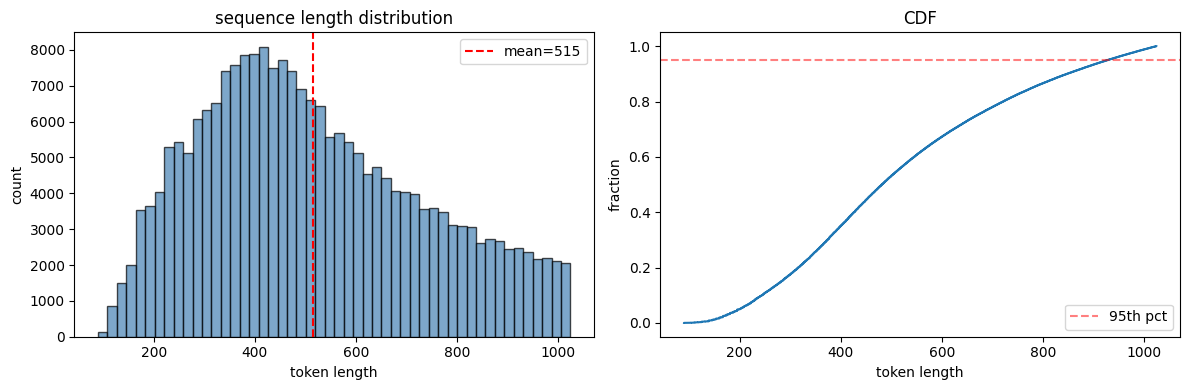

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(lengths, bins=50, color='steelblue', edgecolor='k', alpha=0.7)
ax1.axvline(lengths.mean(), color='red', ls='--', label=f'mean={lengths.mean():.0f}')
ax1.set_xlabel('token length')
ax1.set_ylabel('count')
ax1.set_title('sequence length distribution')
ax1.legend()

sl = np.sort(lengths)
ax2.plot(sl, np.arange(1, len(sl)+1)/len(sl))
ax2.axhline(0.95, color='red', ls='--', alpha=0.5, label='95th pct')
ax2.set_xlabel('token length')
ax2.set_ylabel('fraction')
ax2.set_title('CDF')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{DRIVE}/plots/seq_lengths.png', dpi=150)
plt.show()

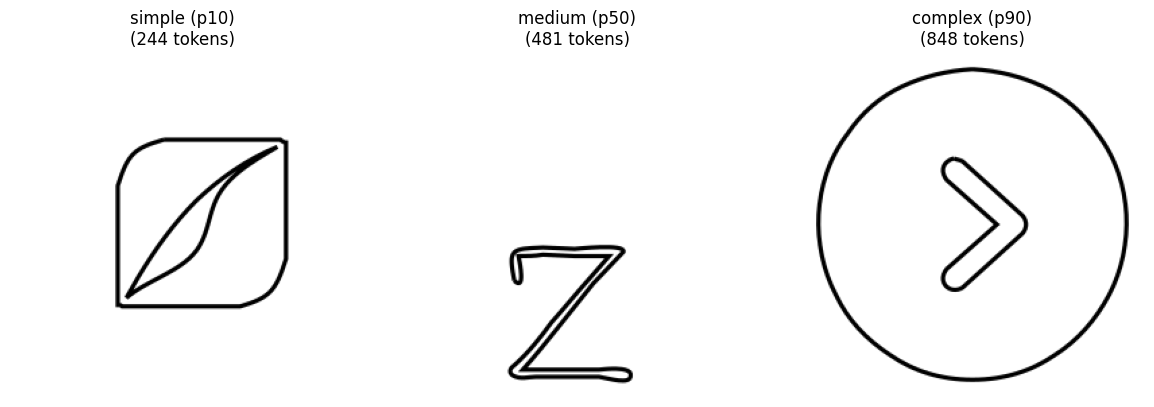

In [10]:
# render examples at different complexity levels
try:
    import cairosvg
    from PIL import Image

    idx_sorted = np.argsort(lengths)
    examples = {
        'simple (p10)':  idx_sorted[len(idx_sorted)//10],
        'medium (p50)':  idx_sorted[len(idx_sorted)//2],
        'complex (p90)': idx_sorted[int(len(idx_sorted)*0.9)],
    }

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for i, (label, idx) in enumerate(examples.items()):
        svg_text = tok.decode(tokenized[idx][1:-1])
        try:
            png = cairosvg.svg2png(bytestring=svg_text.encode(), output_width=256, output_height=256)
            axes[i].imshow(Image.open(BytesIO(png)))
        except Exception as e:
            axes[i].text(0.5, 0.5, f'render failed\n{str(e)[:40]}',
                        ha='center', va='center', transform=axes[i].transAxes, fontsize=8)
        axes[i].set_title(f'{label}\n({lengths[idx]} tokens)')
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig(f'{DRIVE}/plots/svg_examples.png', dpi=150)
    plt.show()
except Exception as e:
    print(f"rendering failed: {e}")

## Done with Part 1Artifacts:- `data/tokenizer.json`, `data/corpus.txt`- `data/train.npy`, `val.npy`, `test.npy`- `data/meta.json`- `plots/seq_lengths.png`, `plots/svg_examples.png`